In [1]:
import sys
sys.path.append("/project/src")

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from sksurv.metrics import integrated_brier_score, cumulative_dynamic_auc, brier_score
from sklearn.metrics import mean_squared_error
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from preprocessing import (
    split_features_target,
    low_missingness_complete_case_analysis,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)
from helpers import (
  save_pic,
  show_pic,
  define_strata
)

import wandb
import joblib

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
    test_df_csv = "/content/drive/MyDrive/bachelor/nacc_test.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"
    test_df_csv = "./data/nacc_test.csv"

In [4]:
train_df = pd.read_csv(train_df_csv, delimiter=',')
test_df = pd.read_csv(test_df_csv, delimiter=',')

/tmp/ipykernel_2242/2510053026.py:2: DtypeWarning: Columns (4,8,27,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,190,193,195,201,203,205,207,209,211,217,219,223,227,233,235,237,245,370,372,394,405,545,576,601,672,689,706,760,763,805,813,814,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_df_csv, delimiter=',')


In [5]:
test_df = define_strata(test_df)

In [6]:
train_df.shape

(6484, 142)

In [7]:
test_df.shape

(3496, 857)

In [8]:
train_X, train_y = split_features_target(train_df)

# Cross-Validation results

In [9]:
cox_pipeline = joblib.load("joblib-storage/cox_best_pipeline.joblib")
preprocessor = cox_pipeline.named_steps['preprocessor']
cox = cox_pipeline.named_steps['model']

In [10]:
cv_cindex = joblib.load("joblib-storage/cox_best_cv_cindex.joblib")
cv_cindex_std = joblib.load("joblib-storage/cox_best_cv_cindex_std.joblib")
print(f"Best CV C-index: {cv_cindex:.4f} ± {cv_cindex_std:.4f}")

Best CV C-index: 0.7705 ± 0.0252


# Evaluaition on test dataset

In [11]:
fitted_low_missingness_cols = preprocessor.get_low_missingness_cols()
test_preprepared_df = low_missingness_complete_case_analysis(test_df, low_missingness_columns=fitted_low_missingness_cols)
test_X_raw, test_y = split_features_target(test_preprepared_df)
test_X = preprocessor.transform(test_X_raw)

Complete-case analysis on low-missing columns
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [12]:
test_events = test_y[SURVIVAL_EVENT_COL].astype(bool)
test_times = test_y[SURVIVAL_TIME_COL]

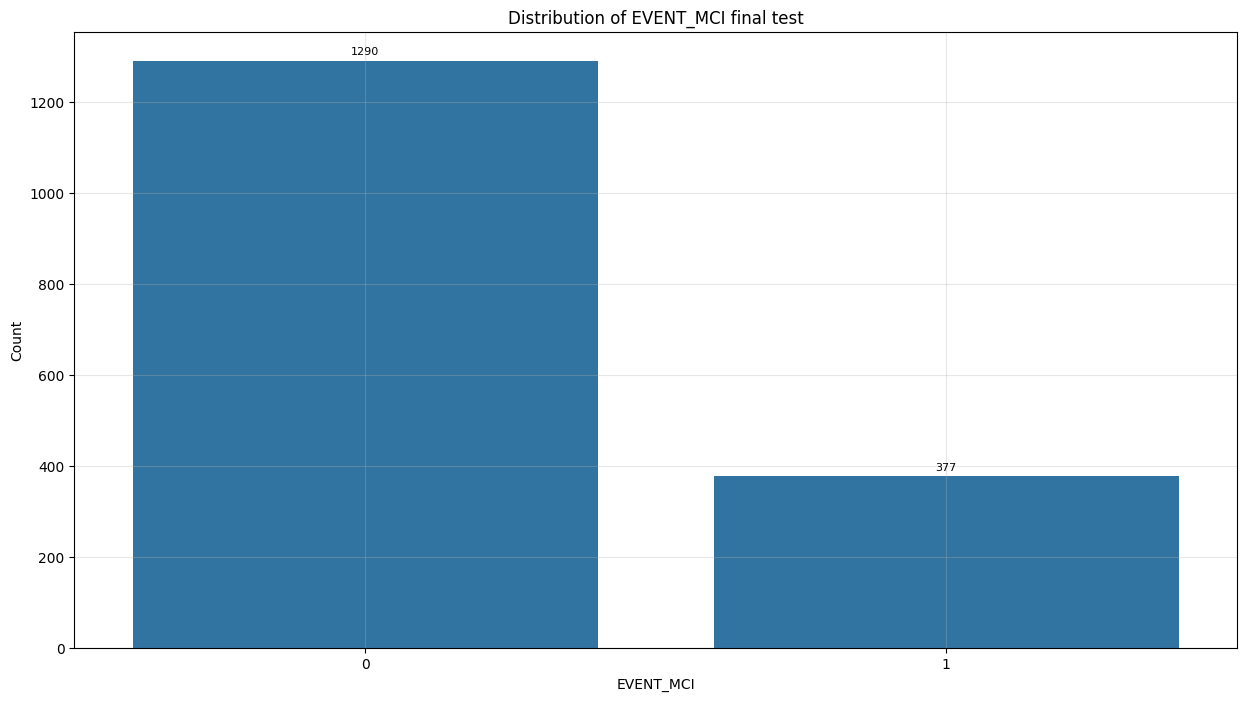

In [13]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=test_preprepared_df['EVENT_MCI'].value_counts().index, y=test_preprepared_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI final test')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
test_preprepared_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.773845
1    0.226155
Name: proportion, dtype: float64

In [15]:
test_X.shape

(1667, 293)

## Test c-index

In [16]:
cindex_test = cox.score(test_X, test_y)
print(f"Test C-index: {cindex_test:.4f}")

Test C-index: 0.7689


## Test IBS

In [17]:
def calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time):
    times_ibs = np.linspace(event_min_time, event_max_time, 100)

    surv_probs_by_time = cox.predict_survival_function(test_X, times=times_ibs)
    # IBS expect matric in format (n_patients, n_timepoints), so we need to transpose the matrix
    T_surv_matrix = surv_probs_by_time.values.T

    ibs = integrated_brier_score(train_y, test_y, T_surv_matrix, times_ibs)
    print(f"Integrated Brier Score: {ibs:.4f}")

    return ibs

In [18]:
event_min_time = test_times[test_events].min()
event_max_time = test_times[test_events].max()
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

Event times range from 0.82 to 18.17 years


In [19]:
follow_up_ibs = calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time)

Integrated Brier Score: 0.2324


In [20]:
event_min_time = test_times[test_events].min()
event_max_time = 5
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

ibs_5_years = calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time)

Event times range from 0.82 to 5.00 years
Integrated Brier Score: 0.1084


## Test KM and Survival curve

In [21]:
kmf = KaplanMeierFitter()
kmf.fit(test_times, event_observed=test_events)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1667 total observations, 1290 right-censored observations>

In [22]:
predicted_surv = cox.predict_survival_function(test_X).mean(axis=1)
predicted_surv.head(5)

0.145    0.999782
0.468    0.999624
0.652    0.999624
0.690    0.999249
0.726    0.999090
dtype: float64

In [23]:
test_times_min = test_times.min()
test_times_max = test_times.max()
times_to_plot = np.linspace(test_times_min, test_times_max, 100)

In [24]:
brier_times = np.arange(int(test_times_min)+1, int(test_times_max)+1)
brier_score_df = cox.predict_survival_function(test_X, times=brier_times)
brier_scores_T = brier_score_df.values.T

_, brier_scores = brier_score(train_y, test_y, brier_scores_T, brier_times)
brier_scores

array([0.01249193, 0.07752285, 0.11267928, 0.15034477, 0.17266905,
       0.19057216, 0.20486468, 0.22367074, 0.23759904, 0.26102587,
       0.27276777, 0.28805643, 0.30614528, 0.33624611, 0.31822054,
       0.29064553, 0.30672211, 0.32504873, 0.16952508])

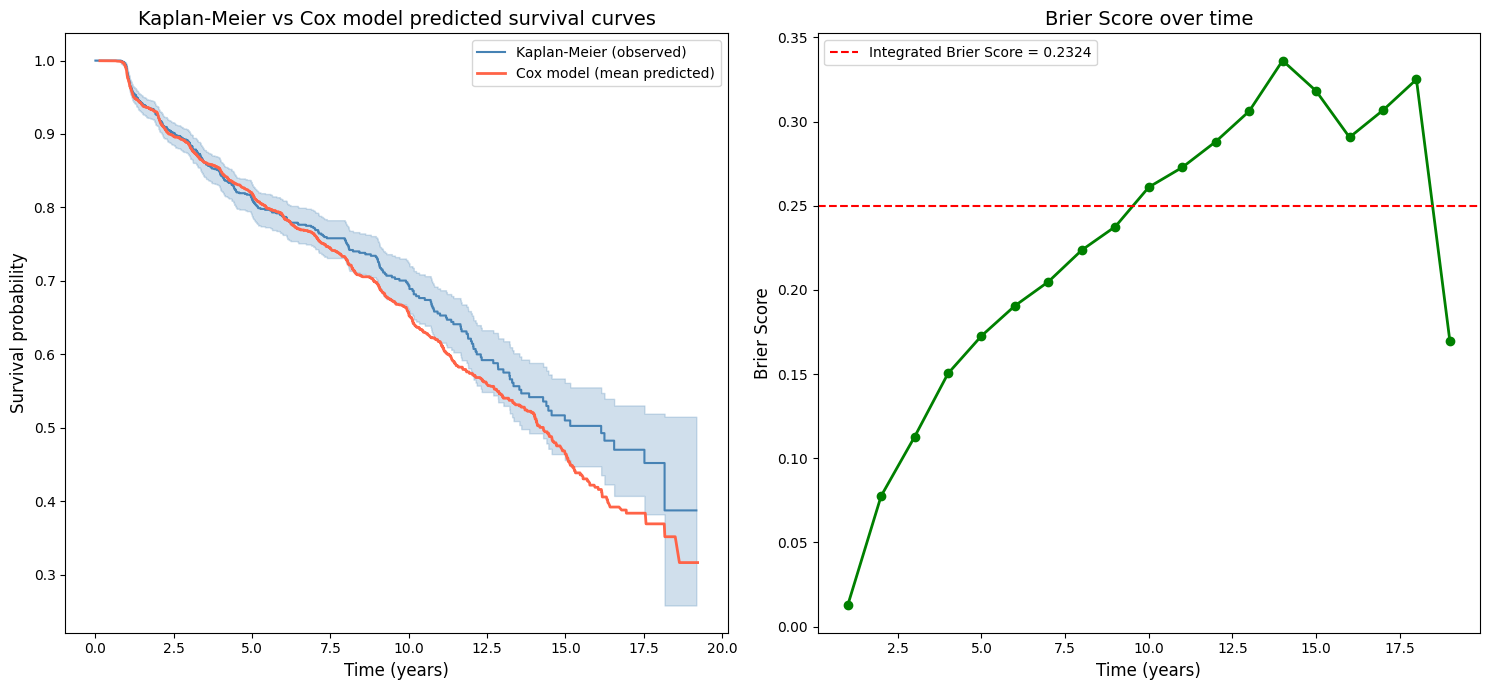

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
kmf.plot_survival_function(ax=ax[0], label="Kaplan-Meier (observed)", color="steelblue")
ax[0].plot(predicted_surv.index, predicted_surv.values, color="tomato", linewidth=2, label="Cox model (mean predicted)")
ax[0].set_xlabel("Time (years)", fontsize=12)
ax[0].set_ylabel("Survival probability", fontsize=12)
ax[0].set_title("Kaplan-Meier vs Cox model predicted survival curves", fontsize=14)
ax[0].legend()  

ax[1].plot(brier_times, brier_scores, color="green", marker="o", linewidth=2)
ax[1].axhline(0.25, color="red", linestyle="--", label=f"Integrated Brier Score = {follow_up_ibs:.4f}")
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[1].set_ylabel("Brier Score", fontsize=12)
ax[1].set_title("Brier Score over time", fontsize=14)
ax[1].legend()
plt.tight_layout()
save_pic(plt, "cox_evaluation_KM_IBS.png")
plt.show()

In [26]:
times = np.linspace(test_times_min, test_times_max, 100)
pred_surv = cox.predict_survival_function(test_X, times=times).values.T
predicted_mean = np.mean(pred_surv, axis=0)
kmf_surv_scores = kmf.survival_function_at_times(times).values

abs_errors = np.abs(kmf_surv_scores - predicted_mean)

rmse      = np.sqrt(mean_squared_error(kmf_surv_scores, predicted_mean))
median_ae = np.median(abs_errors)
mean_ae   = np.mean(abs_errors)

print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.0430
Median Abs Error: 0.0312
Mean Abs Error:   0.0329


## Risk groups

In [27]:
risk_scores = cox.predict_partial_hazard(test_X).values

risk_df = pd.DataFrame({
  "scores": risk_scores,
  "event": test_events,
  "duration": test_times
})
risk_df.head()

,scores,event,duration
0,0.366123,False,14.144
1,1.007178,False,2.086
2,0.358579,False,14.541
3,0.798545,False,0.854
4,0.803604,False,4.036


In [28]:
stable_patients = risk_df[risk_df["event"] == False].copy()
converted_patients = risk_df[risk_df["event"] == True].copy()
stable_patients_scores = stable_patients["scores"]
converted_patients_scores = converted_patients["scores"]

print(f"cMCI risk scores: min={stable_patients_scores.min():.2f}, max={stable_patients_scores.max():.2f}, median={stable_patients_scores.median():.2f}")
print(f"pMCI risk scores: min={converted_patients_scores.min():.2f}, max={converted_patients_scores.max():.2f}, median={converted_patients_scores.median():.2f}")

cMCI risk scores: min=0.13, max=18.46, median=0.82
pMCI risk scores: min=0.21, max=27.98, median=1.49


In [29]:
NUMBER_OF_BINS = 80

In [30]:
bin_edges = np.linspace(converted_patients["scores"].min(), converted_patients["scores"].max(), NUMBER_OF_BINS + 1)
low_medium_cutoff = np.percentile(converted_patients["scores"], 33.333)
medium_high_cutoff = np.percentile(converted_patients["scores"], 66.667)

low_risk = converted_patients[converted_patients["scores"] <= low_medium_cutoff]['scores'].values
medium_risk = converted_patients[(converted_patients["scores"] > low_medium_cutoff) & ( converted_patients["scores"] <= medium_high_cutoff)]['scores'].values
high_risk = converted_patients[converted_patients["scores"] > medium_high_cutoff]['scores'].values

print(f"Low risk group:    {len(low_risk)} patients")
print(f"Medium risk group: {len(medium_risk)} patients")
print(f"High risk group:   {len(high_risk)} patients")

Low risk group:    126 patients
Medium risk group: 125 patients
High risk group:   126 patients


In [31]:
LOW_RISK_GROUP_INDICATOR = 0
MEDIUM_RISK_GROUP_INDICATOR = 1
HIGH_RISK_GROUP_INDICATOR = 2

def assign_patient_to_risk_group(score, low_cutoff, high_cutoff):
    if score <= low_cutoff:
        return LOW_RISK_GROUP_INDICATOR
    elif score <= high_cutoff:
        return MEDIUM_RISK_GROUP_INDICATOR
    else:
        return HIGH_RISK_GROUP_INDICATOR

In [32]:
converted_patients["risk_group"] = converted_patients["scores"].apply(lambda s: assign_patient_to_risk_group(s, low_medium_cutoff, medium_high_cutoff))
converted_patients.head()

,scores,event,duration,risk_group
6,2.374591,True,3.211,2
9,1.386647,True,8.030,1
12,3.866195,True,1.916,2
18,5.809015,True,1.793,2
19,9.518846,True,2.012,2


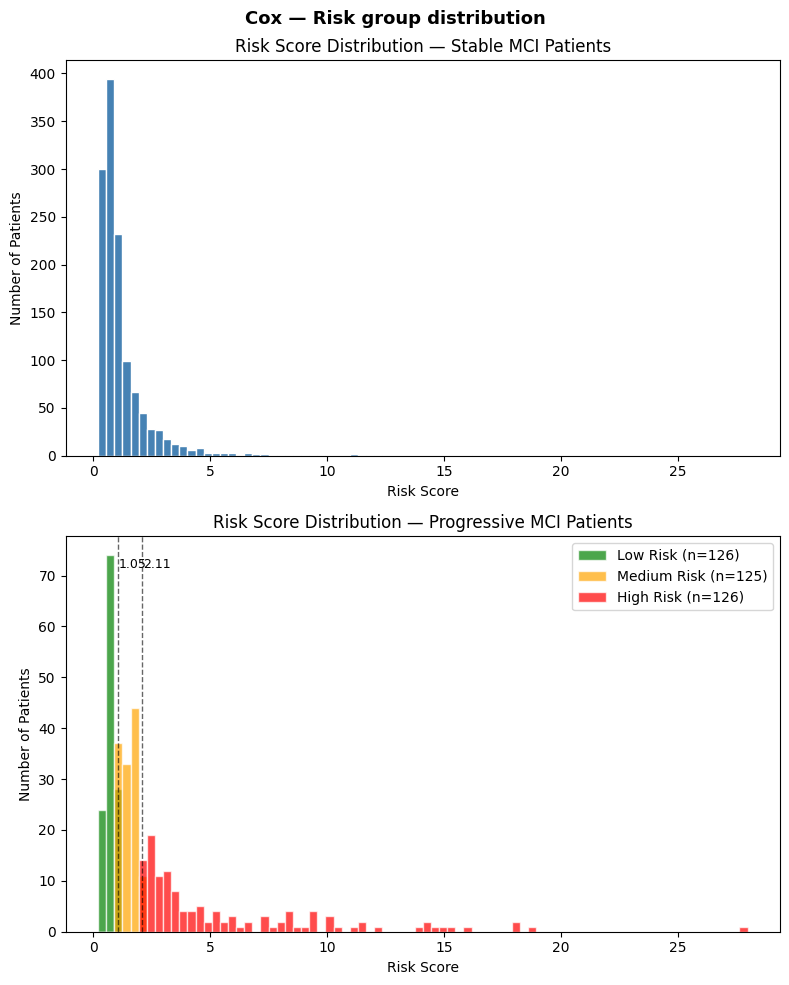

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].hist(stable_patients_scores, bins=bin_edges, color="steelblue", edgecolor="white")
axes[0].set_title("Risk Score Distribution — Stable MCI Patients", fontsize=12)
axes[0].set_xlabel("Risk Score", fontsize=10)
axes[0].set_ylabel("Number of Patients", fontsize=10)

axes[1].hist(low_risk, bins=bin_edges, color="green", label=f"Low Risk (n={len(low_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(medium_risk, bins=bin_edges, color="orange", label=f"Medium Risk (n={len(medium_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(high_risk, bins=bin_edges, color="red", label=f"High Risk (n={len(high_risk)})", edgecolor="white", alpha=0.7)
axes[1].legend(fontsize=10)
axes[1].set_title("Risk Score Distribution — Progressive MCI Patients", fontsize=12)
axes[1].set_xlabel("Risk Score", fontsize=10)
axes[1].set_ylabel("Number of Patients", fontsize=10)

axes[1].axvline(low_medium_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axvline(medium_high_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
ymax = axes[1].get_ylim()[1]
axes[1].text(low_medium_cutoff + 0.05, ymax * 0.92, f'{low_medium_cutoff:.2f}', fontsize=9, color='black')
axes[1].text(medium_high_cutoff + 0.05, ymax * 0.92, f'{medium_high_cutoff:.2f}', fontsize=9, color='black')

plt.suptitle("Cox — Risk group distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
save_pic(plt, "cox_evaluation_Risk_Groups.png")
plt.show()

In [34]:
converted_patients.groupby('risk_group')['scores'].mean()

risk_group
0    0.714104
1    1.519463
2    5.674982
Name: scores, dtype: float64

In [62]:
test_times_min = test_times.min()
test_times_max = test_times.max()
test_times = np.linspace(test_times_min, test_times_max, 100)

surv_curve = cox.predict_survival_function(test_X, times=test_times).values.T
conv_curve = 1 - surv_curve 

group_cdf = {}
for grp in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = (risk_df["risk_group"] == grp).values
    group_cdf[grp] = conv_curve[mask].mean(axis=0)

# Value at 4 years = last point on the curve
print(f"Predicted conversion probability within {test_times_min} to {test_times_max} years:")
for grp, name in [(LOW_RISK_GROUP_INDICATOR, "low"),
                  (MEDIUM_RISK_GROUP_INDICATOR, "medium"),
                  (HIGH_RISK_GROUP_INDICATOR, "high")]:
    print(f"  {name:<7} risk: {group_cdf[grp][-1]*100:.1f}%")

Predicted conversion probability within 0.816 to 19.179 years:
  low     risk: 68.2%
  medium  risk: 69.1%
  high    risk: 67.8%


### Analyse significance of group separation

In [35]:
overall = multivariate_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
overall.print_summary()
print(f"Overall log-rank p-value: {overall.p_value:.20f}")

pairwise = pairwise_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
pairwise.print_summary()

Overall log-rank p-value: 0.00000000000000009012


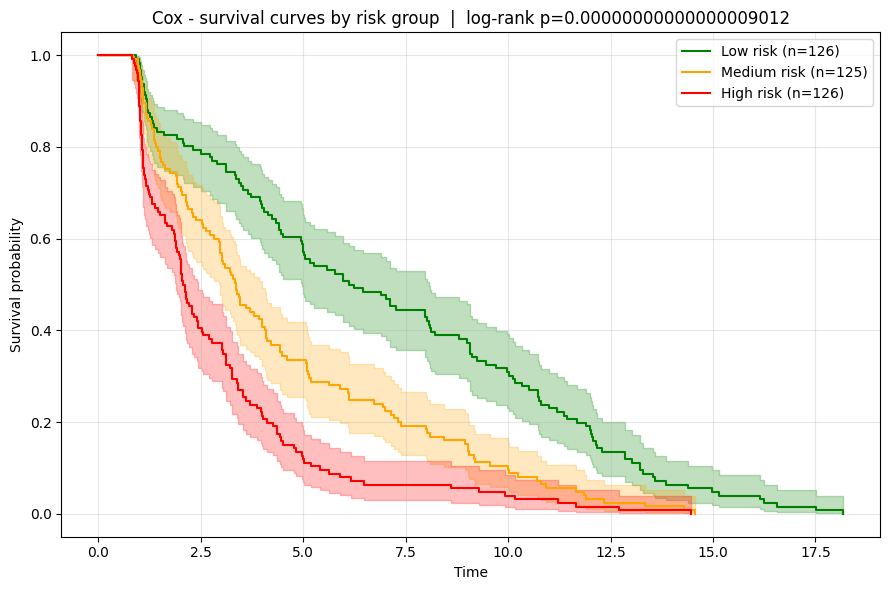

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    LOW_RISK_GROUP_INDICATOR: {"color": 'green', "name": "Low risk"},
    MEDIUM_RISK_GROUP_INDICATOR: {"color": 'orange', "name": "Medium risk"},
    HIGH_RISK_GROUP_INDICATOR: {"color": 'red', "name": "High risk"}
}
kmf = KaplanMeierFitter()

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = converted_patients['risk_group'] == group
    kmf.fit(
        converted_patients.loc[mask, 'duration'],
        converted_patients.loc[mask, 'event'],
        label=f'{colors[group]["name"]} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group]["color"])

ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")
ax.set_title(f"Cox - survival curves by risk group  |  log-rank p={overall.p_value:.20f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_pic(plt, "cox_evaluation_Risk_Groups_KM.png")
plt.show()

## Time dependent ROC-AUC

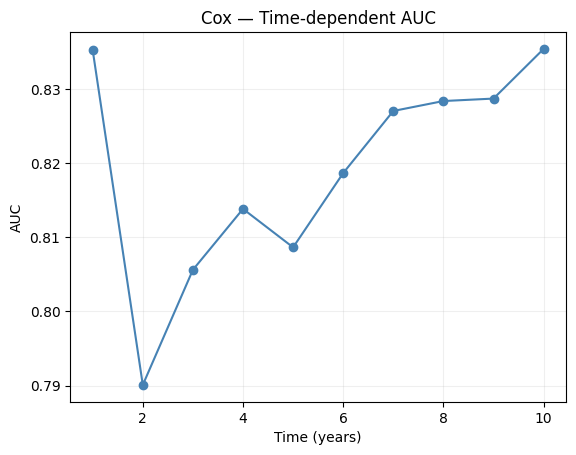

AUC at 1 year(s): 0.8352
AUC at 2 year(s): 0.7901
AUC at 3 year(s): 0.8056
AUC at 4 year(s): 0.8138
AUC at 5 year(s): 0.8086
AUC at 6 year(s): 0.8187
AUC at 7 year(s): 0.8270
AUC at 8 year(s): 0.8284
AUC at 9 year(s): 0.8287
AUC at 10 year(s): 0.8354
Mean AUC:          0.8139


In [37]:
times_roc   = np.arange(1, 11)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

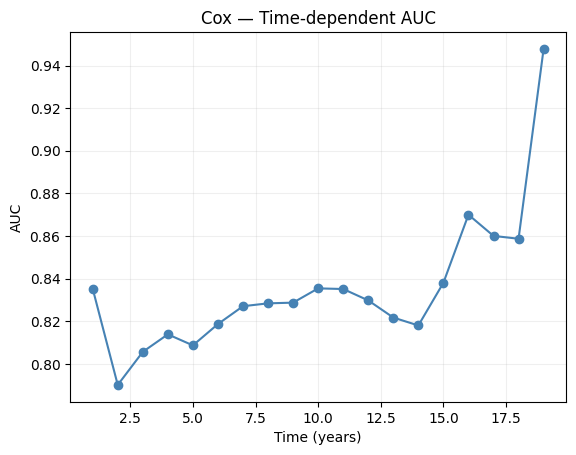

AUC at 1 year(s): 0.8352
AUC at 2 year(s): 0.7901
AUC at 3 year(s): 0.8056
AUC at 4 year(s): 0.8138
AUC at 5 year(s): 0.8086
AUC at 6 year(s): 0.8187
AUC at 7 year(s): 0.8270
AUC at 8 year(s): 0.8284
AUC at 9 year(s): 0.8287
AUC at 10 year(s): 0.8354
AUC at 11 year(s): 0.8351
AUC at 12 year(s): 0.8298
AUC at 13 year(s): 0.8217
AUC at 14 year(s): 0.8180
AUC at 15 year(s): 0.8380
AUC at 16 year(s): 0.8700
AUC at 17 year(s): 0.8600
AUC at 18 year(s): 0.8587
AUC at 19 year(s): 0.9478
Mean AUC:          0.8367


In [38]:
times_roc   = np.arange(int(test_times_min)+1, int(test_times_max) + 1)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

Using timepoints: [1, 3, 5]
AUC scores: [0.83523922 0.80561909 0.80864926]


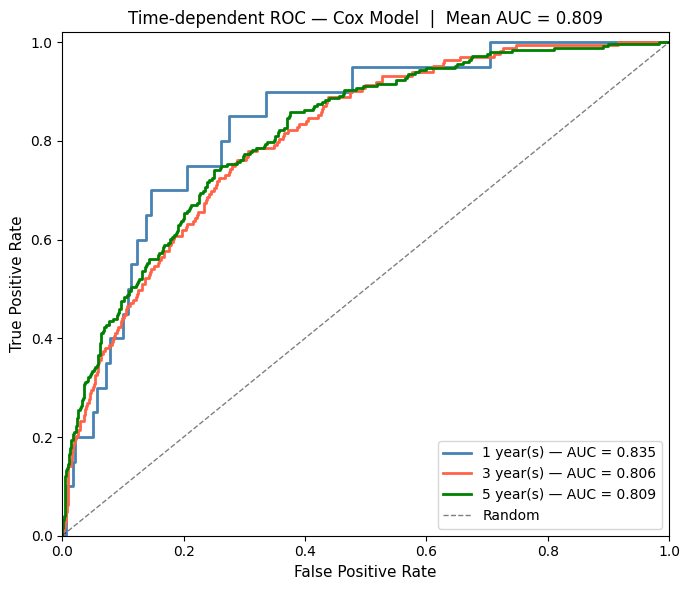

In [39]:
from sklearn.metrics import roc_curve
from sksurv.metrics import cumulative_dynamic_auc
import matplotlib.pyplot as plt

times_roc = [1, 3, 5]
print(f"Using timepoints: {times_roc}")

risk_scores  = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(
    train_y, test_y, risk_scores, times_roc
)
print(f"AUC scores: {auc_scores}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'tomato', 'green']

for t, auc_val, color in zip(times_roc, auc_scores, colors):
    known_mask    = (test_y[SURVIVAL_EVENT_COL].astype(bool)) | (test_y[SURVIVAL_TIME_COL] >= t)
    y_true_binary = ((test_y[SURVIVAL_EVENT_COL].astype(bool)) &(test_y[SURVIVAL_TIME_COL] <= t))[known_mask].astype(int)
    risk_known    = risk_scores[known_mask]

    fpr, tpr, _   = roc_curve(y_true_binary, risk_known)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{t} year(s) — AUC = {auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"Time-dependent ROC — Cox Model  |  Mean AUC = {mean_auc:.3f}",
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
save_pic(plt, "cox_evaluation_ROC_AUCs.png")
plt.show()

# Summary results

## CV C-index

In [51]:
print(f"CV C-index: {cv_cindex:.2f} ± {cv_cindex_std:.2f}")

CV C-index: 0.77 ± 0.03


## Test C-index

In [52]:
print(f"Test C-index: {cindex_test:.2f}")

Test C-index: 0.77


## IBS score

In [53]:
print(f"IBS score for the entire follow-up period: {follow_up_ibs:.3f}")
print(f"IBS score for the first 5 years: {ibs_5_years:.3f}")

IBS score for the entire follow-up period: 0.232
IBS score for the first 5 years: 0.108


## KM curve

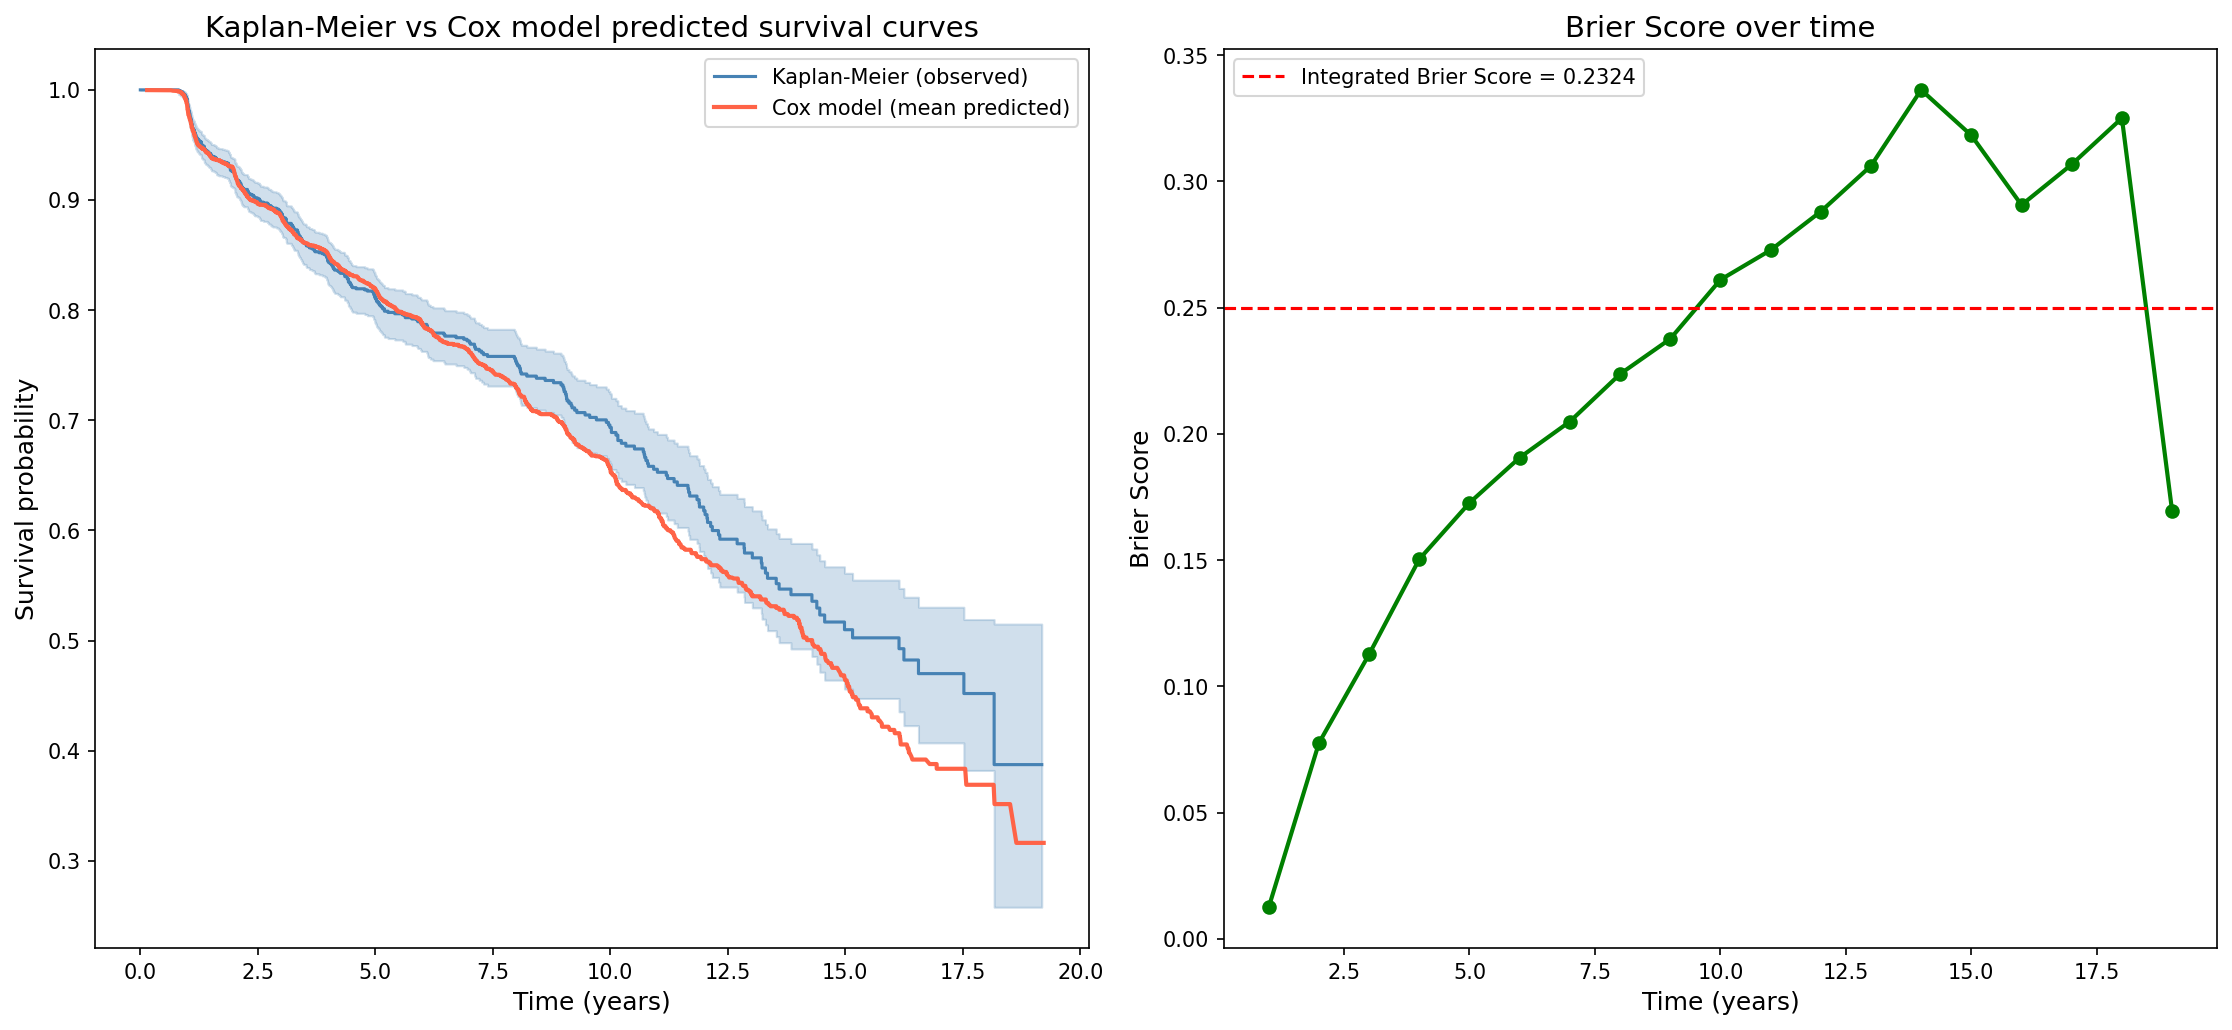

In [43]:
show_pic("cox_evaluation_KM_IBS.png")

In [55]:
print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.0430
Median Abs Error: 0.0312
Mean Abs Error:   0.0329


## Risk groups

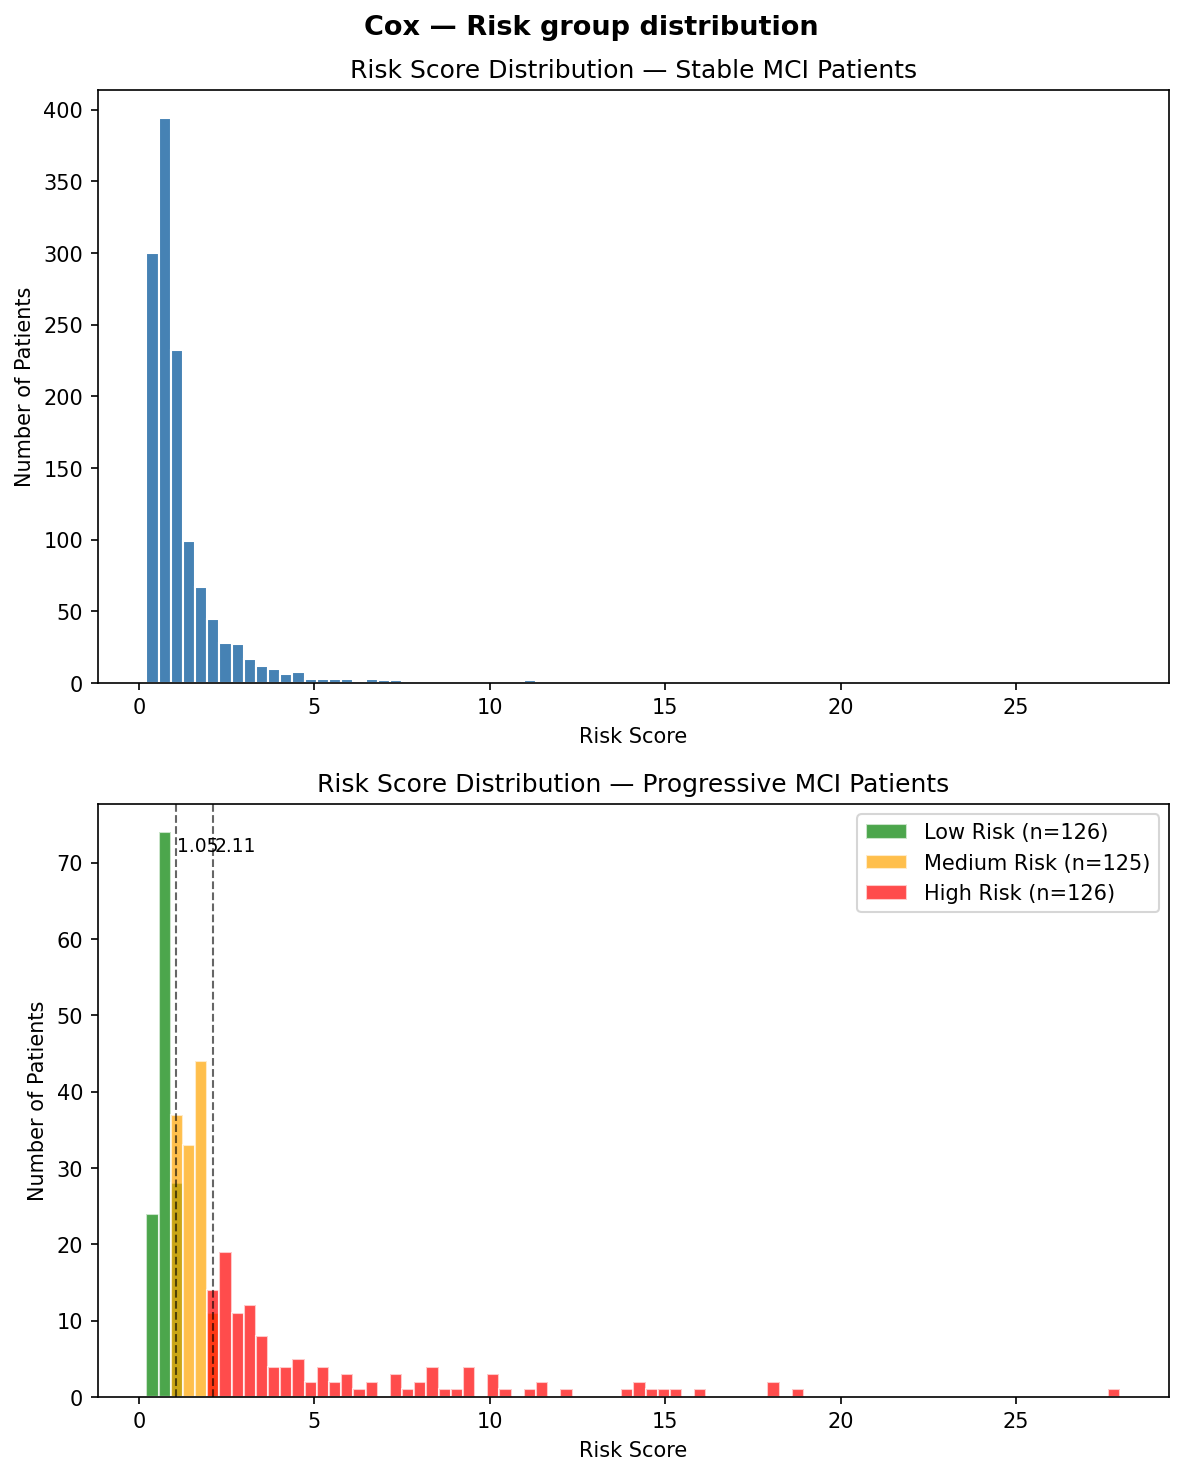

In [44]:
show_pic("cox_evaluation_Risk_Groups.png")

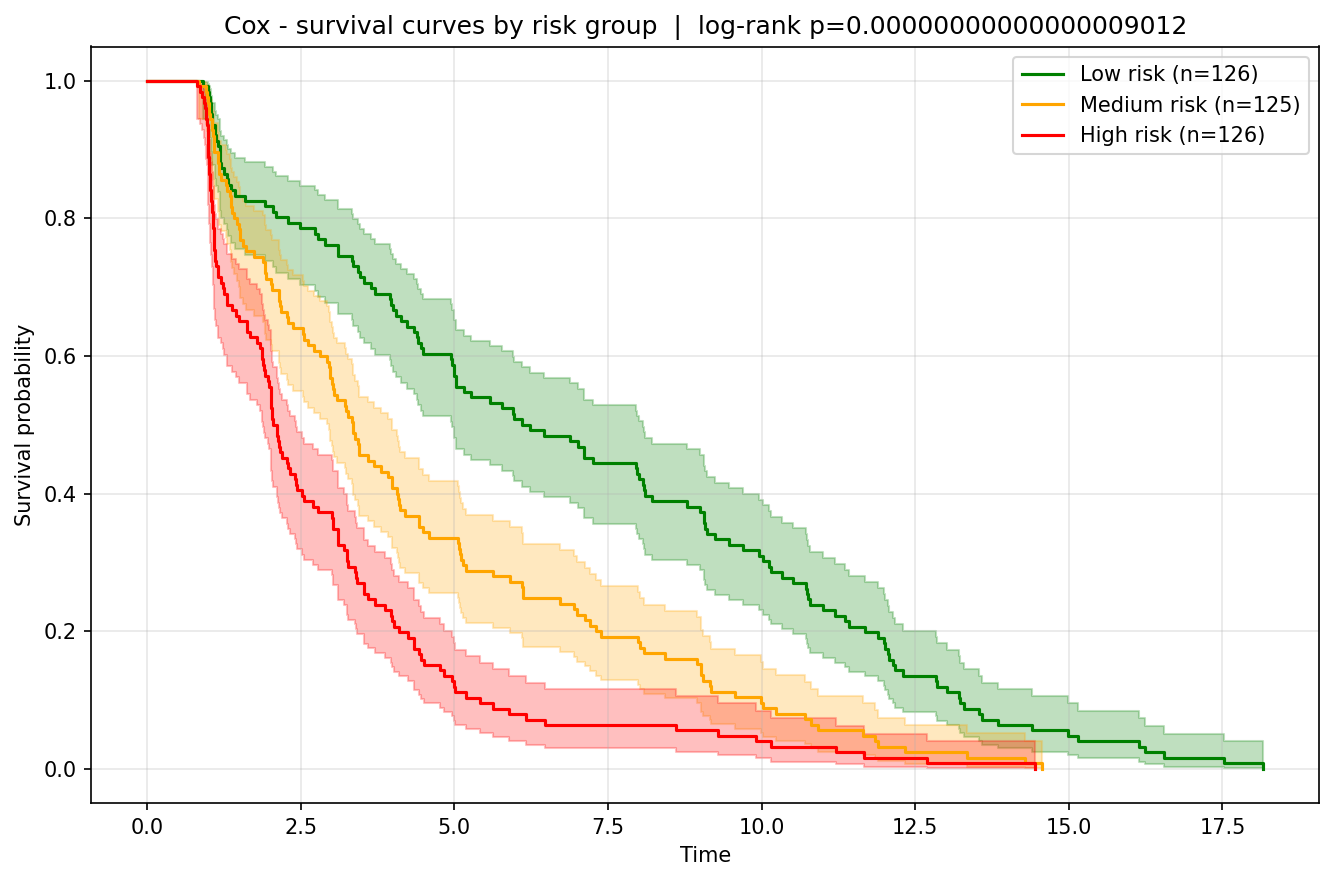

In [45]:
show_pic("cox_evaluation_Risk_Groups_KM.png")

### Risk groups long-rank tests results

In [46]:
pairwise.print_summary()

In [47]:
overall.print_summary()

In [48]:
converted_patients.groupby('risk_group')['scores'].mean().rename(index={0: 'low', 1:'medium', 2: 'high'}) 

risk_group
low       0.714104
medium    1.519463
high      5.674982
Name: scores, dtype: float64

## Integrated ROC-AUC

In [54]:
print(f"Using timepoints (in years): {times_roc}")
print(f"AUC scores: {np.round(auc_scores, 3)}")

Using timepoints (in years): [1, 3, 5]
AUC scores: [0.835 0.806 0.809]


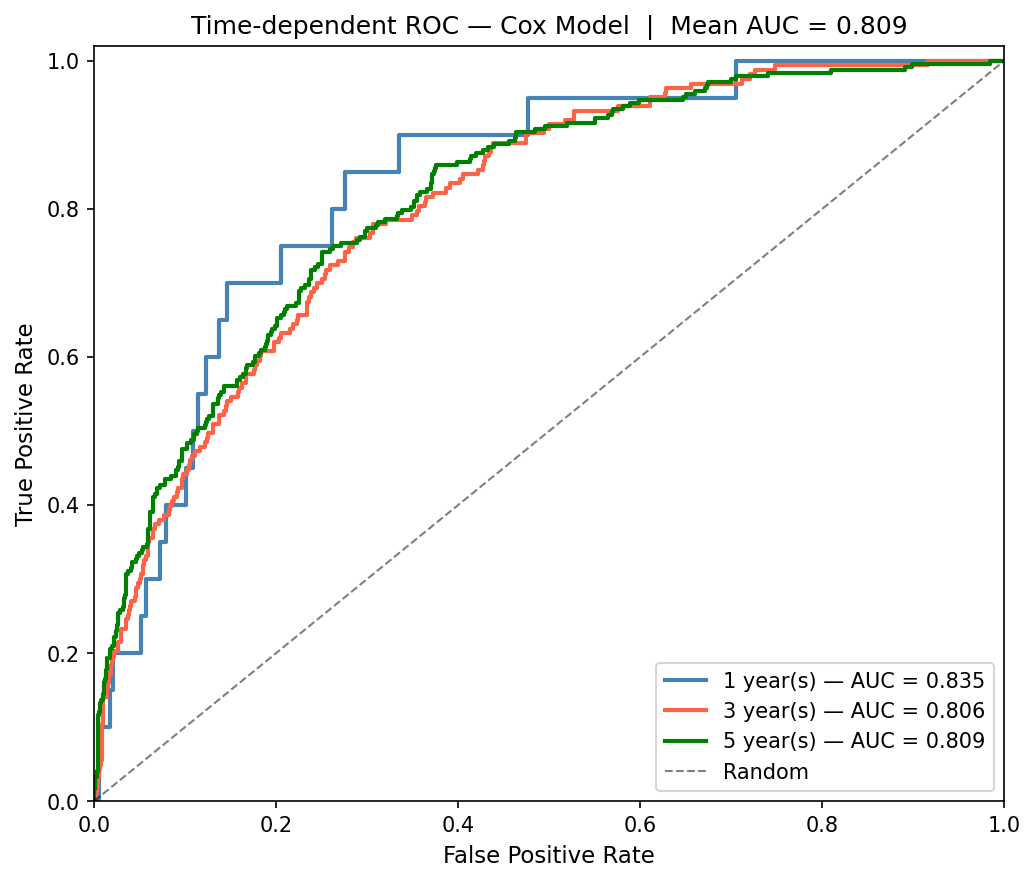

In [50]:
show_pic("cox_evaluation_ROC_AUCs.png")